<div align="center">
    <h1> Control Barrier Functions in Semi-Automated Beverage Blending Equipment<br> 
    <h3> Samantha Becvar <br> University of Washington, Department of Mechanical Engineering Master's Program <br> A A/E E/M E 548 B <br> Prof. Karen Leung
</div>

## **----Section 0: Imports----**

In [8]:
import matplotlib.pyplot as plt
plt.ioff()
import ipynb
from ipynb.fs.full.Sec1_Build_The_Sys import *
plt.ion()

## **----Section 2: Basic PD Controller----**
In this section, a basic PD controller will be built to get a feel for the basic dynamics of the system. 

#### Define Dynamics
**Functions:**
* dynamics(state, control)
* integrate(state, control, dt)

**Equations**
$$
x = \begin{bmatrix} y \\ \dot{y} \end{bmatrix};\ \dot{x} = \begin{bmatrix} \dot{y} \\ \ddot{y} \end{bmatrix}
$$
$$
u = \begin{bmatrix} \ddot{y} \end{bmatrix}
$$

In [2]:
def dynamics(state: Float[Array, "2"], control: Float[Array, "1"]) -> Float[Array, "2"]:
    '''
    The purpose of this function is to define our dynamics
    -----
    Args
        state - a 1x2 array with our x = [pos, velocity] of our blender tip
        control - our control input, in this case it's acceleration
    Returns
        x_dot - a 1x2 array with our x_dot = [velocity, acceleration]
    '''
    # unpack our state
    y, y_dot = state

    # create our dynamics
    x_dot = jnp.array([
        y_dot,
        control
    ])

    return x_dot

def integrate(state: Float[Array, "2"], control: Float[Array, "1"], dt: float) -> Float[Array, "2"]:
    '''
    The purpose is to integrate our dynamics using forward euler integration
    -----
    Args
        state - a 1x2 array with our x = [pos, velocity] of our blender tip
        control - our control input, in this case it's acceleration
        dt - our time step
    Returns
        step - step in time along our dyanmics
    '''
    # define our step
    step = state + dt * dynamics(state, control)

    return step

#### Define a PD Controller
**Functions:**
* pd_controller(state, y_des, y_des_dot, kp, kd)
* reference_trajectory(t)

**Equations:**
$$
u = -k_{p} (y - y_{des}) - k_{d} \dot{y}
$$

In [3]:
def pd_controller(
        state: Float[Array, "2"], 
        y_des: Float[Array, "1"],
        y_dot_des: Float[Array, "1"], 
        kp=30.0, 
        kd=12.0) -> Float[Array, "1"]:
    ''' 
    The purpose of this function is to create a PD Controller that will attempt to get our state towards its desired state
    -----
    Args
        state - a 1x2 array with our x = [pos, velocity] of our blender tip
        y_des - desired position
        y_des_dot - desired velocity
        kp - proprtional gain value
        kd - derivative gain value
    Returns
        u - PD control based on current state
    '''
    # unpack our state
    y, y_dot = state

    # create our PD control
    u = - kp * (y - y_des) - kd * y_dot

    return u

In [4]:
def reference_trajectory(home: float, t: float) -> Float[Array, "2"]:
    '''
    The purpose of this function is to create our desired state--our "blending profile"
    -----
    Args
        home - the starting position of the blender tip
        t - time
    Returns
        y_des - desired position of the blender
        y_des_dot - desired velocity of the blender
    '''
    # Start at Home
    if t < 1.0:
        y_des = home
        y_des_dot = 0.0

    # Approach the Cup
    elif t < 4.0:
        y_des = 9.5
        y_des_dot = -1.0

    # Blend Stroke
    elif t < 11.0:
        center = 5
        amplitude = 2.5
        omega = 2 * jnp.pi * 0.7

        y_des = (center + amplitude * jnp.sin(omega * (t - 3.0)))
        y_des_dot = (amplitude * omega * jnp.cos(omega * (t - 3.0)))

    # Prepare to Leave Cup
    elif t < 14.0:
        y_des = 9.5
        y_des_dot = 1.0

    # Retract back Home
    elif t < 17.0:
        y_des = home
        y_des_dot = 1.0
    
    # Be Home
    else:
        y_des = home
        y_des_dot = 0.0

    return jnp.array([y_des, y_des_dot])

#### Stop & Check: PD Controller

In [5]:
''' Set-Up for our Simulated PD Controller '''
# define our time
T = 20.0
DT = 0.01
# define our steps
N = int(T / DT)
# define our state
state = jnp.array([14.0, 0.0])
home = state[0]

# set-up our book keeping arrays
times = []
positions = []
velocities = []
accelerations = []

''' Run our Simulated PD Controller'''
for k in range(N):
    # define our time
    t = k * DT

    # create our reference trajectory for the time
    y_des, y_des_dot = reference_trajectory(home, t)

    # create our control
    u = pd_controller(
        state, 
        y_des,
        y_des_dot
    )

    # update our state
    state = integrate(
        state,
        u,
        DT
    )

    times.append(t)
    positions.append(state[0])
    velocities.append(state[1])
    accelerations.append(u)

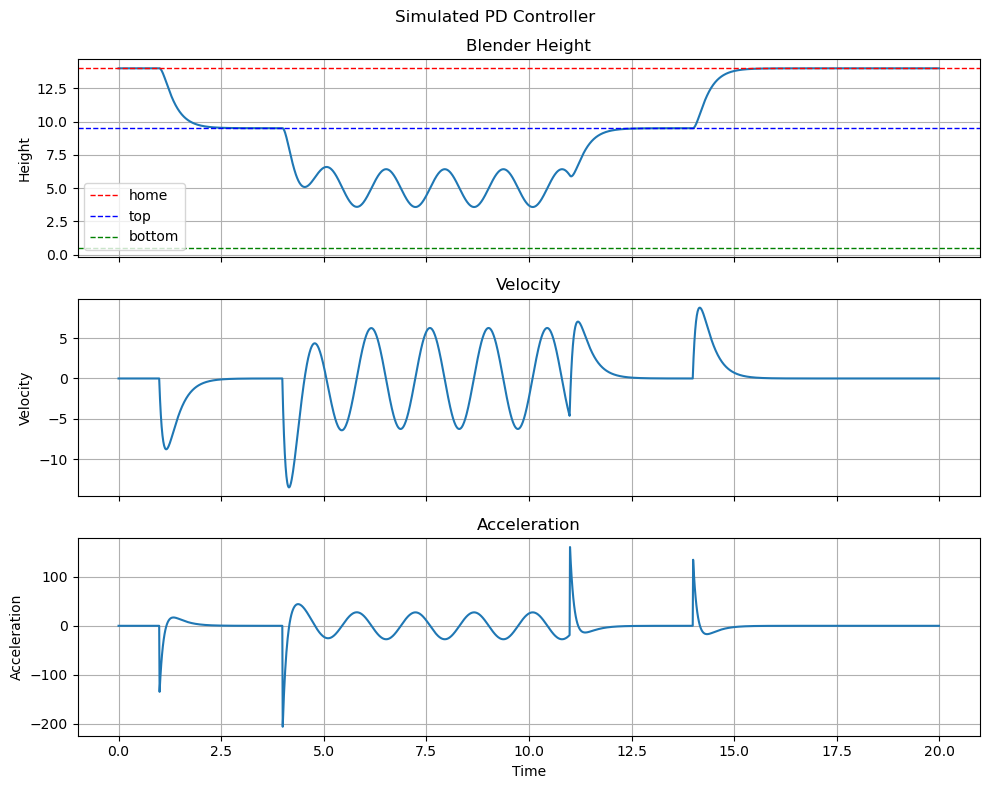

In [6]:
''' Create Plots of our Simulated PD Controller'''
# create our figure and axes
fig_pd, axs_pd = plt.subplots(
    3,
    1,
    figsize=(10, 8),
    sharex = True
)

axs_pd[0].plot(times, positions)
axs_pd[0].set_ylabel("Height")
axs_pd[0].set_title("Blender Height")
axs_pd[0].axhline(
        home,
        color='red',
        linestyle='--',
        linewidth=1,
        label="home"
    )
axs_pd[0].axhline(
        9.5,
        color='blue',
        linestyle='--',
        linewidth=1,
        label="top"
    )
axs_pd[0].axhline(
        0.5,
        color='green',
        linestyle='--',
        linewidth=1,
        label="bottom"
    )
axs_pd[0].legend()

axs_pd[1].plot(times, velocities)
axs_pd[1].set_ylabel("Velocity")
axs_pd[1].set_title("Velocity")

axs_pd[2].plot(times, accelerations)
axs_pd[2].set_ylabel("Acceleration")
axs_pd[2].set_xlabel("Time")
axs_pd[2].set_title("Acceleration")

for ax in axs_pd:
    ax.grid(True)

fig_pd.suptitle("Simulated PD Controller")
plt.tight_layout()
plt.show()

MovieWriter Pillow unavailable; using Pillow instead.


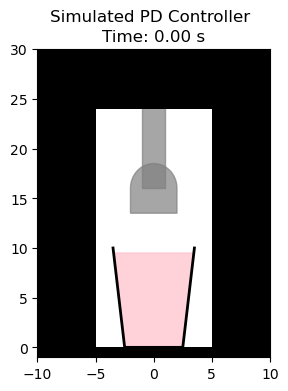

In [7]:
''' Animate our Simulated PD Controller '''
''' Definitions '''
# environment dimensions
env_dims_pd = jnp.array([
    [-10, 10],    # (x_min, x_max)
    [-1, 30]    # (y_min, y_max)
])
# black box dimensions
box_sizes_pd = jnp.array([
    [10, 1],    # bottom box, (width, height)
    [14, 6],    # top box, (width, height)
    [5, 32],    # left box, (width, height)
    [5, 32]    # right box, (width, height)
])
box_centers_pd = jnp.array([
    [0, -0.5],  # bottom box, (center_x, center_y)
    [0, 27],    # top box, (center_x, center_y) 
    [-7.5, 14], # left box, (center_x, center_y)
    [7.5, 14]  # right box, (center_x, center_y)
])
# cup dimensions
cup_dims_pd = jnp.array([
    5,  # bottom width
    7,  # top width
    0,  # center location
    10  # height
])

''' Create the Plot '''
# create the figure and axis
fig2_pd, ax2_pd = plt.subplots(figsize=(3, 4))
fig2_pd.suptitle("Simulated PD Controller")

''' Create the Animation '''
def animate(frame):

    ax2_pd.clear()

    draw_environment(
        ax2_pd,
        env_dims_pd,
        box_sizes_pd,
        box_centers_pd,
        cup_dims_pd,
        "pink"
    )

    blender_height_pd = positions[frame]
    blender(ax2_pd, blender_height_pd)

    ax2_pd.grid(False)
    ax2_pd.set_title(
        f"Time: {times[frame]:.2f} s"
    )


ani = FuncAnimation(
    fig2_pd,
    animate,
    frames=len(positions),
    interval=30
)

ani.save("pd_controller_animation.gif", writer="Pillow", fps=30)

# HTML(ani.to_jshtml())